In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir('/mnt/workspace/tvae')
print(f"Working directory: {os.getcwd()}")

data = np.load('data/processed/1.npz', allow_pickle=True)
print('Files:', data.files)
print('Windows shape:', data['windows'].shape)
print('Scaler mean [CGM, PI, RA]:', data['scaler_mean'])
print('Scaler std  [CGM, PI, RA]:', data['scaler_std'])
print('Modality:', data['modality'])
print('Patient ID:', data['patient_id'])

Working directory: /mnt/workspace/tvae
Files: ['windows', 'scaler_mean', 'scaler_std', 'patient_id', 'modality']
Windows shape: (1252, 288, 10)
Scaler mean [CGM, PI, RA]: [ 1.6128477e+02 -1.8154923e+00  9.5683351e-02]
Scaler std  [CGM, PI, RA]: [61.86241    2.586747   0.3660857]
Modality: ['AID']
Patient ID: ['1']


Windows with carbs: 380


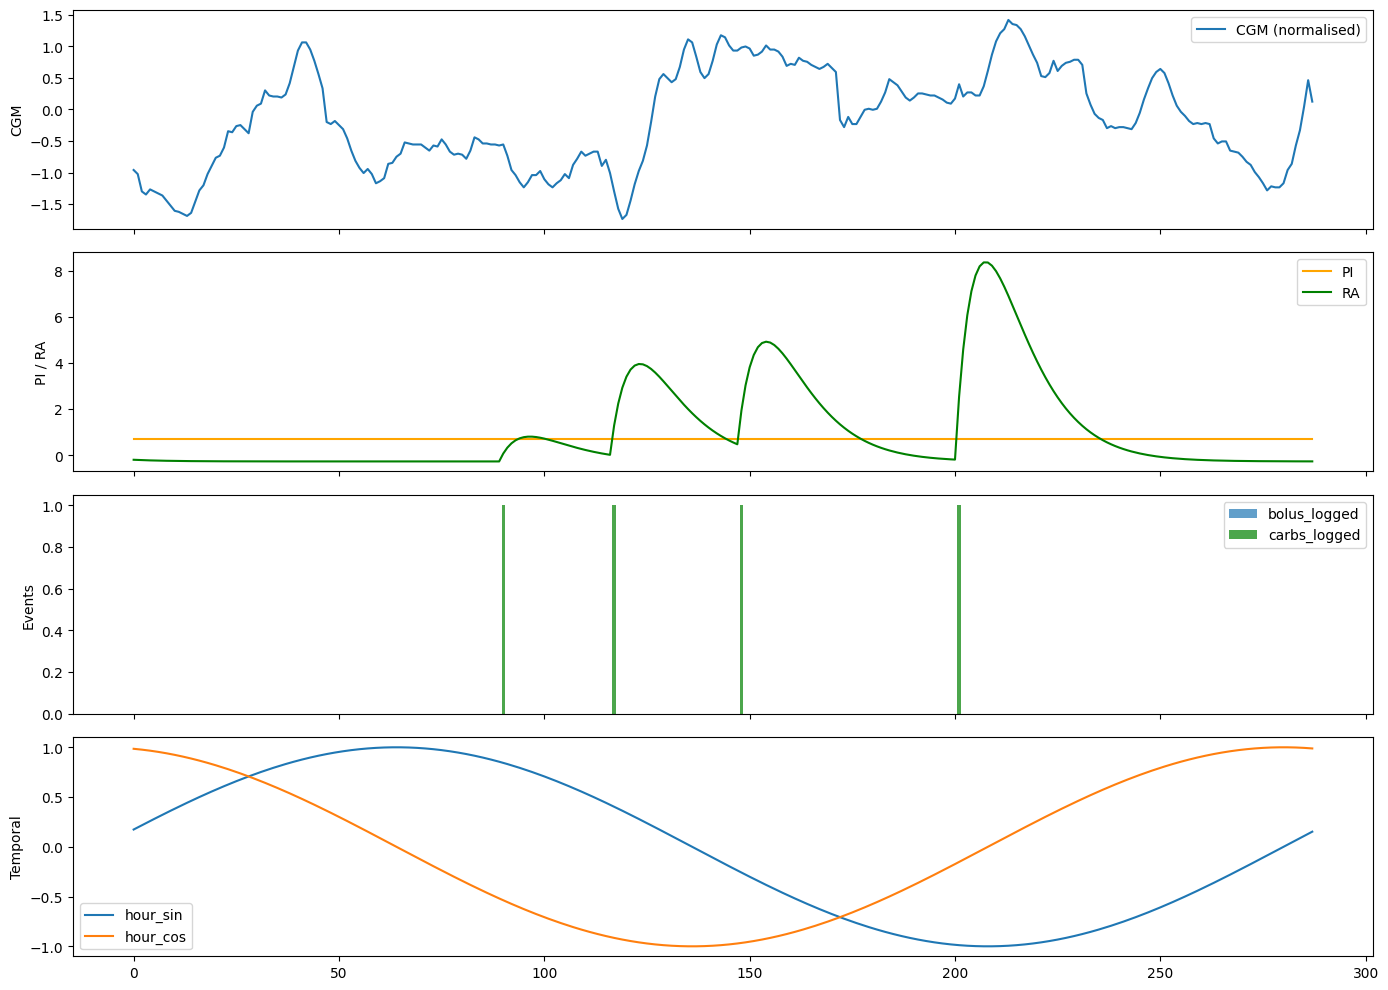

In [3]:
FEATURES = ['CGM', 'PI', 'RA', 'hour_sin', 'hour_cos',
            'bolus_logged', 'carbs_logged', 'AID', 'SAP', 'MDI']

# Coge una ventana del mediodía — busca una con carbs
windows = data['windows']
carbs_idx = 6  # carbs_logged
windows_with_carbs = np.where(windows[:, :, carbs_idx].sum(axis=1) > 0)[0]
print(f"Windows with carbs: {len(windows_with_carbs)}")

# Plot la primera ventana con carbs
w = windows[windows_with_carbs[0]]
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(w[:, 0], label='CGM (normalised)')
axes[0].set_ylabel('CGM'); axes[0].legend()

axes[1].plot(w[:, 1], label='PI', color='orange')
axes[1].plot(w[:, 2], label='RA', color='green')
axes[1].set_ylabel('PI / RA'); axes[1].legend()

axes[2].bar(range(288), w[:, 5], label='bolus_logged', alpha=0.7)
axes[2].bar(range(288), w[:, 6], label='carbs_logged', alpha=0.7, color='green')
axes[2].set_ylabel('Events'); axes[2].legend()

axes[3].plot(w[:, 3], label='hour_sin')
axes[3].plot(w[:, 4], label='hour_cos')
axes[3].set_ylabel('Temporal'); axes[3].legend()

plt.tight_layout()
plt.savefig('plots/11_preprocessing_validation_patient1.png', dpi=100)
plt.show()

MDI patient: T_256.npz
Windows shape: (33, 288, 10)
Scaler mean [CGM, PI, RA]: [164.70644     -0.56014466   0.57743055]
Scaler std  [CGM, PI, RA]: [45.513645   0.3726762  2.0138464]


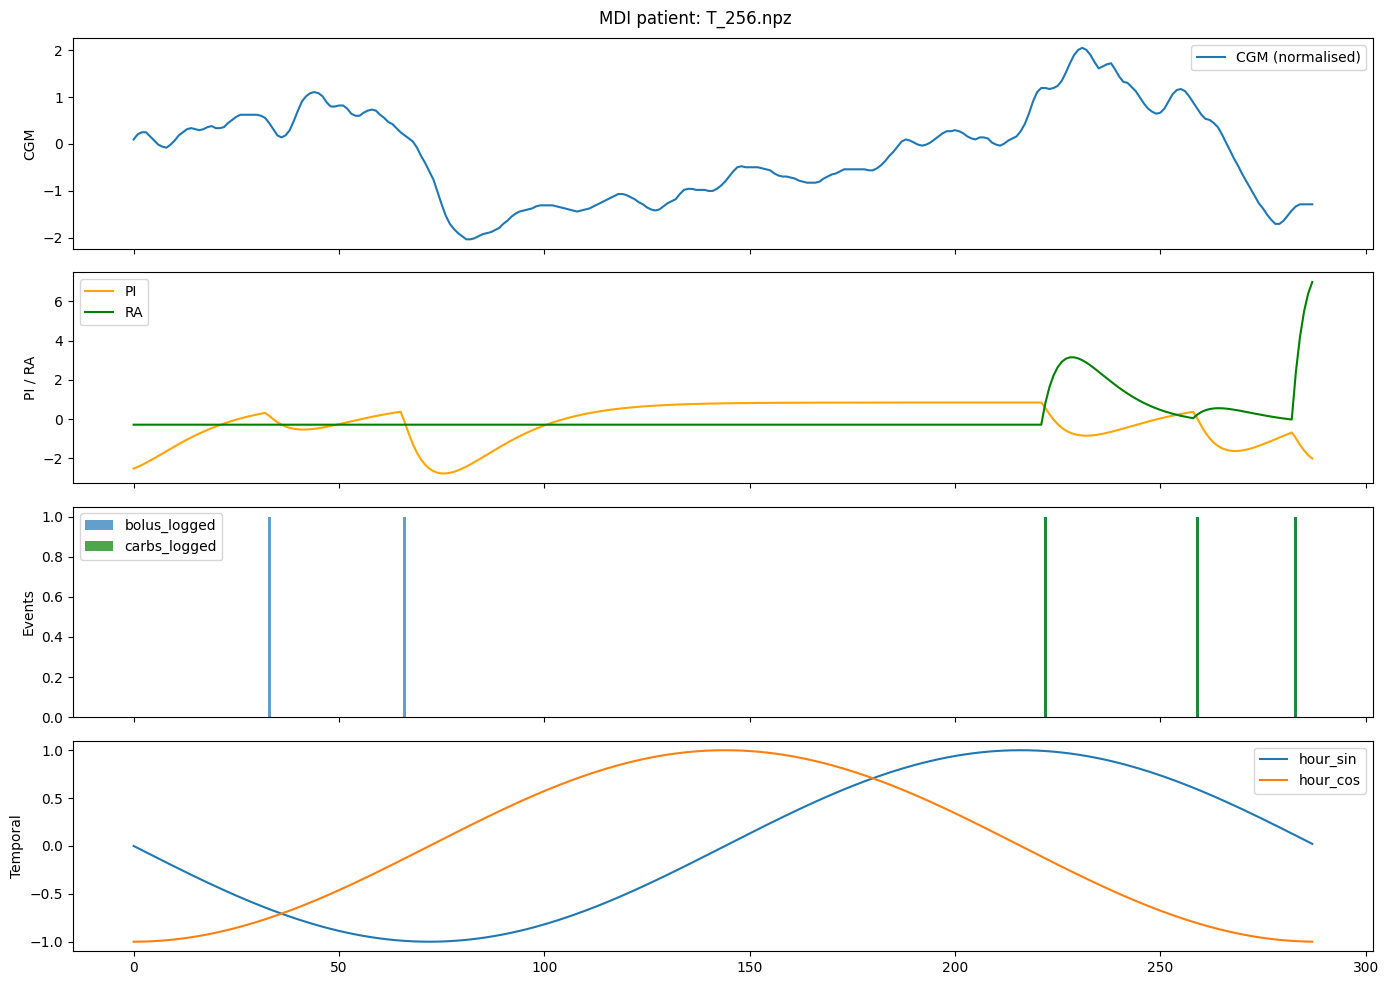

In [4]:
# Busca un paciente MDI

mdI_patient = None
for f in os.listdir('data/processed/'):
    d = np.load(f'data/processed/{f}', allow_pickle=True)
    if d['modality'][0] == 'MDI':
        mdi_patient = f
        break

print(f"MDI patient: {mdi_patient}")
data_mdi = np.load(f'data/processed/{mdi_patient}', allow_pickle=True)
print('Windows shape:', data_mdi['windows'].shape)
print('Scaler mean [CGM, PI, RA]:', data_mdi['scaler_mean'])
print('Scaler std  [CGM, PI, RA]:', data_mdi['scaler_std'])

windows = data_mdi['windows']
windows_with_carbs = np.where(windows[:, :, 6].sum(axis=1) > 0)[0]
w = windows[windows_with_carbs[0]]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(w[:, 0], label='CGM (normalised)')
axes[0].set_ylabel('CGM'); axes[0].legend()
axes[1].plot(w[:, 1], label='PI', color='orange')
axes[1].plot(w[:, 2], label='RA', color='green')
axes[1].set_ylabel('PI / RA'); axes[1].legend()
axes[2].bar(range(288), w[:, 5], label='bolus_logged', alpha=0.7)
axes[2].bar(range(288), w[:, 6], label='carbs_logged', alpha=0.7, color='green')
axes[2].set_ylabel('Events'); axes[2].legend()
axes[3].plot(w[:, 3], label='hour_sin')
axes[3].plot(w[:, 4], label='hour_cos')
axes[3].set_ylabel('Temporal'); axes[3].legend()
plt.suptitle(f'MDI patient: {mdi_patient}')
plt.tight_layout()
plt.savefig('plots/11b_preprocessing_validation_mdi.png', dpi=100)
plt.show()

In [5]:
import os

stats = {'AID': [], 'SAP': [], 'MDI': []}

for f in os.listdir('data/processed/'):
    d = np.load(f'data/processed/{f}', allow_pickle=True)
    modality = d['modality'][0]
    if modality not in stats:
        continue
    windows = d['windows']  # (N, 288, 10)
    bolus_all_zero = (windows[:, :, 5].sum(axis=1) == 0).mean()
    stats[modality].append(bolus_all_zero)

for mod, values in stats.items():
    print(f"{mod} (n={len(values)}) — ventanas sin bolus_logged: {np.mean(values)*100:.1f}%")

AID (n=813) — ventanas sin bolus_logged: 13.1%
SAP (n=158) — ventanas sin bolus_logged: 7.9%
MDI (n=31) — ventanas sin bolus_logged: 12.1%


Ventanas con carbs Y bolus: 9


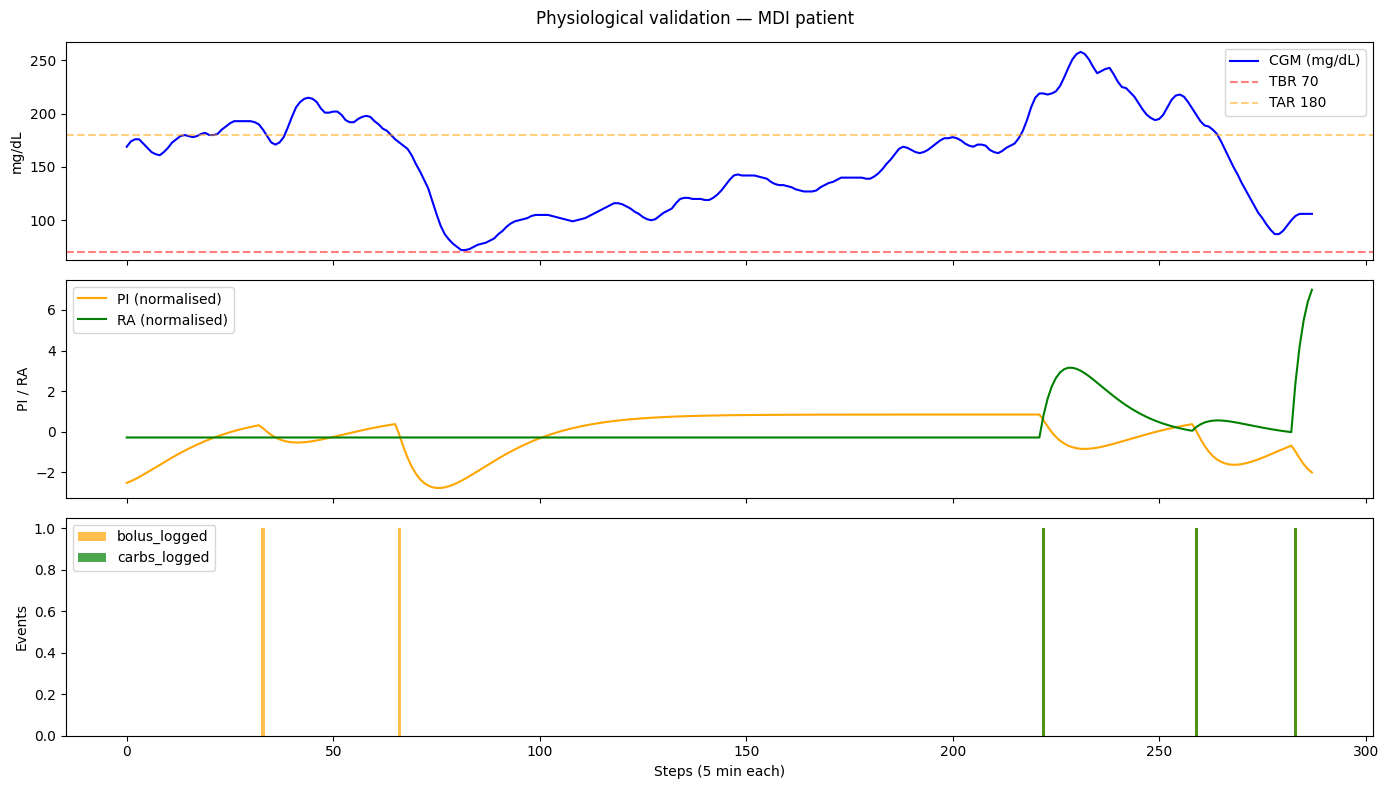

In [6]:
# Validación fisiológica — busca una ventana con carbs Y bolus en el mismo día
# Usa un paciente MDI que tiene señales más informativas

windows = data_mdi['windows']

# Busca ventana con carbs Y bolus
carbs_and_bolus = np.where(
    (windows[:, :, 5].sum(axis=1) > 0) &  # bolus
    (windows[:, :, 6].sum(axis=1) > 0)    # carbs
)[0]
print(f"Ventanas con carbs Y bolus: {len(carbs_and_bolus)}")

w = windows[carbs_and_bolus[0]]

# Desnormaliza CGM para ver valores reales
mean_cgm = data_mdi['scaler_mean'][0]
std_cgm  = data_mdi['scaler_std'][0]
cgm_real = w[:, 0] * std_cgm + mean_cgm

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(cgm_real, label='CGM (mg/dL)', color='blue')
axes[0].axhline(70,  color='red',   linestyle='--', alpha=0.5, label='TBR 70')
axes[0].axhline(180, color='orange', linestyle='--', alpha=0.5, label='TAR 180')
axes[0].set_ylabel('mg/dL'); axes[0].legend()

axes[1].plot(w[:, 1], label='PI (normalised)', color='orange')
axes[1].plot(w[:, 2], label='RA (normalised)', color='green')
axes[1].set_ylabel('PI / RA'); axes[1].legend()

axes[2].bar(range(288), w[:, 5], label='bolus_logged', alpha=0.7, color='orange')
axes[2].bar(range(288), w[:, 6], label='carbs_logged', alpha=0.7, color='green')
axes[2].set_ylabel('Events'); axes[2].legend()

plt.xlabel('Steps (5 min each)')
plt.suptitle('Physiological validation — MDI patient')
plt.tight_layout()
plt.savefig('plots/12_physiological_validation.png', dpi=100)
plt.show()

AID: 20000 ventanas


/tmp/ipykernel_101680/1679883561.py:17: RuntimeWarning: invalid value encountered in divide
  return np.where(den > 0, num / den, np.nan)


SAP: 20000 ventanas
MDI: 1178 ventanas


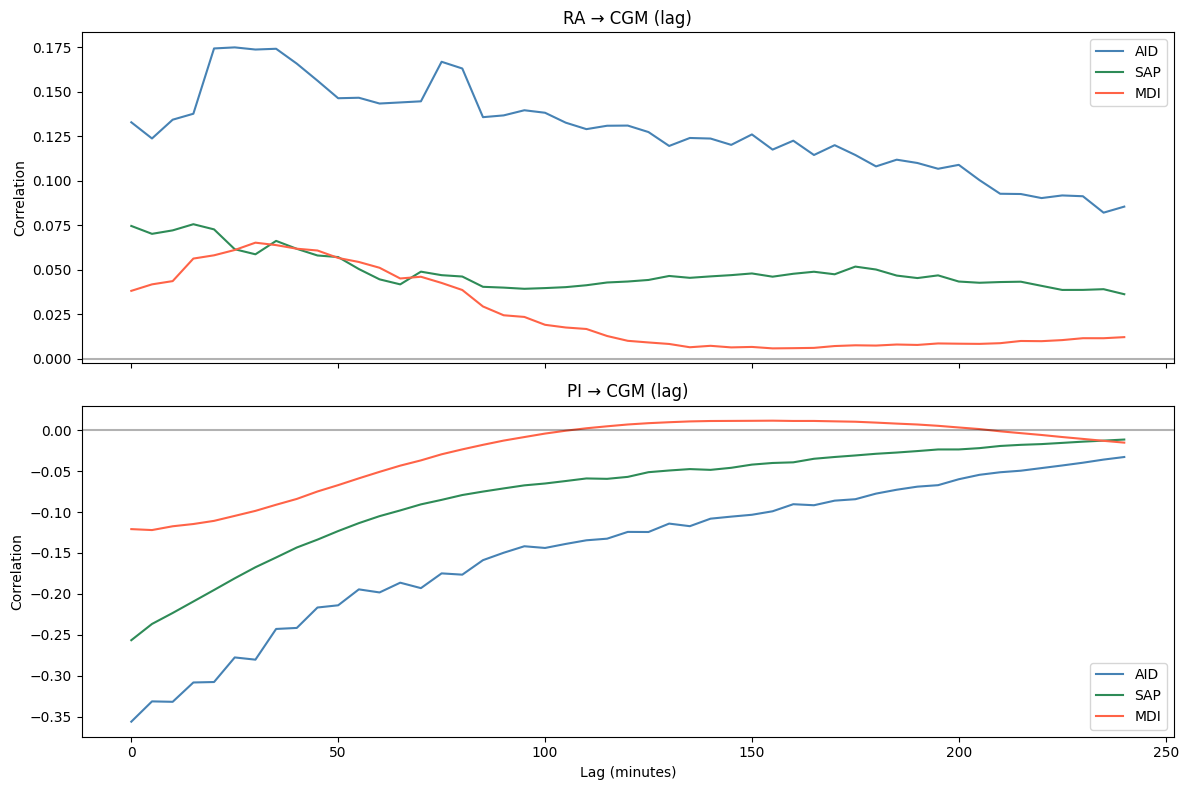

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gc

np.random.seed(42)
all_files = os.listdir('data/processed/')
max_lag = 48
lags = np.arange(0, max_lag + 1)
target = 20_000

def pearson_vec(x, y):
    x = x - x.mean(axis=1, keepdims=True)
    y = y - y.mean(axis=1, keepdims=True)
    num = (x * y).sum(axis=1)
    den = np.sqrt((x**2).sum(axis=1) * (y**2).sum(axis=1))
    return np.where(den > 0, num / den, np.nan)

colors = {'AID': 'steelblue', 'SAP': 'seagreen', 'MDI': 'tomato'}
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mod in ['AID', 'SAP', 'MDI']:
    chunks = []
    for f in np.random.permutation(all_files):
        d = np.load(f'data/processed/{f}', allow_pickle=True)
        if d['modality'][0] != mod:
            continue
        chunks.append(d['windows'])
        if sum(len(x) for x in chunks) >= target:
            break

    windows = np.concatenate(chunks, axis=0)[:target]
    del chunks
    gc.collect()
    print(f"{mod}: {windows.shape[0]} ventanas")

    cgm = windows[:, :, 0]
    pi  = windows[:, :, 1]
    ra  = windows[:, :, 2]
    del windows
    gc.collect()

    ra_corrs, pi_corrs = [], []
    for lag in lags:
        if lag == 0:
            ra_corrs.append(np.nanmean(pearson_vec(ra, cgm)))
            pi_corrs.append(np.nanmean(pearson_vec(pi, cgm)))
        else:
            ra_corrs.append(np.nanmean(pearson_vec(ra[:, :-lag], cgm[:, lag:])))
            pi_corrs.append(np.nanmean(pearson_vec(pi[:, :-lag], cgm[:, lag:])))

    axes[0].plot(lags * 5, ra_corrs, label=mod, color=colors[mod])
    axes[1].plot(lags * 5, pi_corrs, label=mod, color=colors[mod])

    del cgm, pi, ra, ra_corrs, pi_corrs
    gc.collect()

for ax, title in zip(axes, ['RA → CGM (lag)', 'PI → CGM (lag)']):
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_ylabel('Correlation')
    ax.set_title(title)
    ax.legend()

plt.xlabel('Lag (minutes)')
plt.tight_layout()
plt.savefig('plots/13_lagged_correlation_by_modality.png', dpi=100)
plt.show()

AID: 20000 ventanas con carbs


/tmp/ipykernel_101680/3177824194.py:17: RuntimeWarning: invalid value encountered in divide
  return np.where(den > 0, num / den, np.nan)


SAP: 20000 ventanas con carbs
MDI: 495 ventanas con carbs


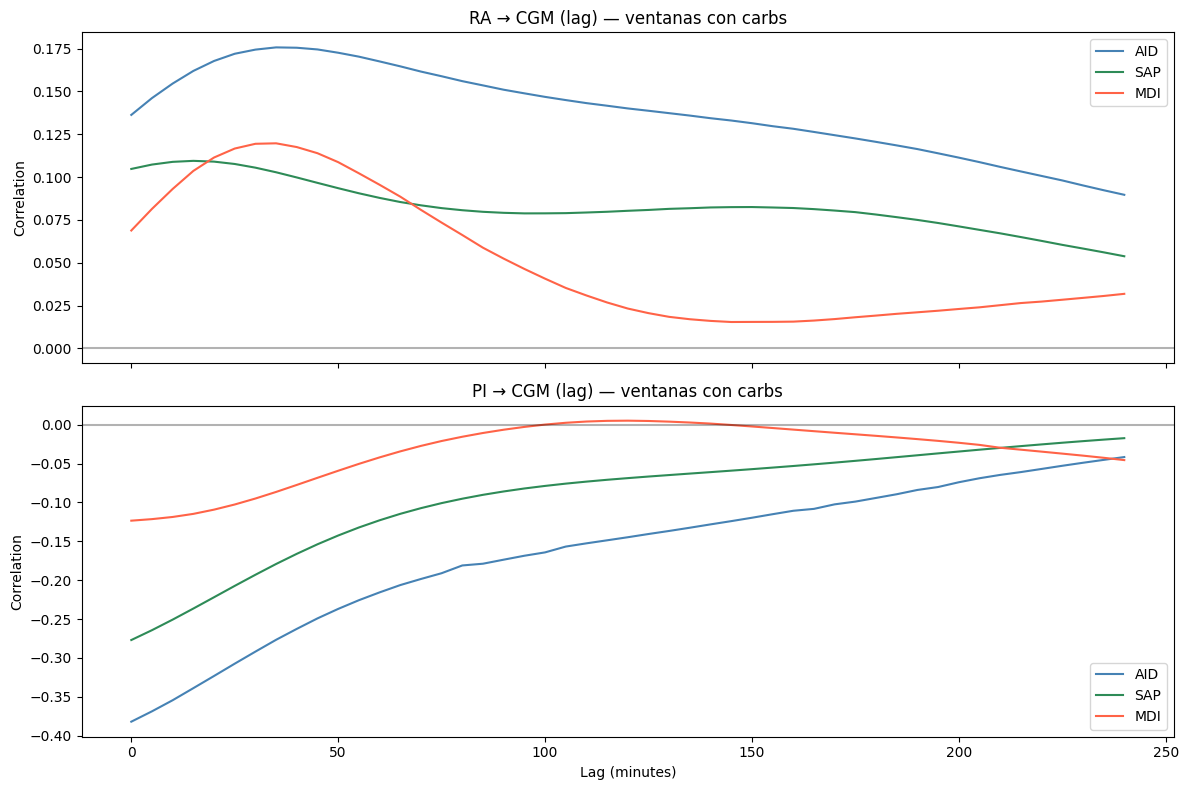

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gc

np.random.seed(42)
all_files = os.listdir('data/processed/')
max_lag = 48
lags = np.arange(0, max_lag + 1)
target = 20_000

def pearson_vec(x, y):
    x = x - x.mean(axis=1, keepdims=True)
    y = y - y.mean(axis=1, keepdims=True)
    num = (x * y).sum(axis=1)
    den = np.sqrt((x**2).sum(axis=1) * (y**2).sum(axis=1))
    return np.where(den > 0, num / den, np.nan)

colors = {'AID': 'steelblue', 'SAP': 'seagreen', 'MDI': 'tomato'}
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mod in ['AID', 'SAP', 'MDI']:
    chunks = []
    for f in np.random.permutation(all_files):
        d = np.load(f'data/processed/{f}', allow_pickle=True)
        if d['modality'][0] != mod:
            continue
        w = d['windows']
        w = w[w[:, :, 6].sum(axis=1) > 0]  # solo ventanas con carbs
        if len(w) > 0:
            chunks.append(w)
        if sum(len(x) for x in chunks) >= target:
            break

    if not chunks:
        print(f"{mod}: sin ventanas con carbs")
        continue

    windows = np.concatenate(chunks, axis=0)[:target]
    del chunks
    gc.collect()
    print(f"{mod}: {windows.shape[0]} ventanas con carbs")

    cgm = windows[:, :, 0]
    pi  = windows[:, :, 1]
    ra  = windows[:, :, 2]
    del windows
    gc.collect()

    ra_corrs, pi_corrs = [], []
    for lag in lags:
        if lag == 0:
            ra_corrs.append(np.nanmean(pearson_vec(ra, cgm)))
            pi_corrs.append(np.nanmean(pearson_vec(pi, cgm)))
        else:
            ra_corrs.append(np.nanmean(pearson_vec(ra[:, :-lag], cgm[:, lag:])))
            pi_corrs.append(np.nanmean(pearson_vec(pi[:, :-lag], cgm[:, lag:])))

    axes[0].plot(lags * 5, ra_corrs, label=mod, color=colors[mod])
    axes[1].plot(lags * 5, pi_corrs, label=mod, color=colors[mod])

    del cgm, pi, ra, ra_corrs, pi_corrs
    gc.collect()

for ax, title in zip(axes, ['RA → CGM (lag) — ventanas con carbs', 
                              'PI → CGM (lag) — ventanas con carbs']):
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_ylabel('Correlation')
    ax.set_title(title)
    ax.legend()

plt.xlabel('Lag (minutes)')
plt.tight_layout()
plt.savefig('plots/13b_lagged_correlation_carbs_only.png', dpi=100)
plt.show()